# A7: PCA Analysis & Cluster Visualization

## Objective
Perform Principal Component Analysis (PCA) on the AIMO observations and visualize the results together with the cluster assignments produced in the clustering task

This notebook documents the complete machine learning analysis performed on the AIMO 
movement assessment dataset. The analysis consists of two main components:

1. **Clustering Analysis**: Identified 2 distinct groups of movement patterns using 
   K-Means clustering after systematic evaluation of multiple algorithms.

2. **Principal Component Analysis (PCA)**: Reduced 40 movement features to 2 principal 
   components for visualization

### Key Findings
- **2 clusters** identified representing Good Performers and Poor Performers
- PCA visualization shows moderate cluster separation along PC1

# Part 1: Clustering Analysis

## 1.1 Objective
Identify natural groupings in the AIMO movement assessment data

## 1.2 Data Preparation

### Features Used
- **Angle Deviation** (13 features): No_1 through No_13_Angle_Deviation
- **NASM Deviation** (25 features): No_1 through No_25_NASM_Deviation  
- **Time Deviation** (2 features): No_1 and No_2_Time_Deviation
  
### Features Excluded
- `EstimatedScore`, `AimoScore`: Derived metric (data leakage)
- `ID`: Identifier only, not a feature

### Preprocessing
**Standardization**: Applied StandardScaler to ensure all features on same scale
   - Mean = 0, Standard Deviation = 1
   - Prevents features with larger ranges from dominating distance calculations

## 1.3 Algorithm Selection

### Algorithms Evaluated

**1. K-Means Clustering**
- Partitioning method: assigns each point to nearest centroid
- Fast, scalable, easy to interpret
- Requires specifying k (number of clusters)

**2. Hierarchical Clustering**
- Builds tree of clusters (dendrogram)
- No need to specify k in advance
- Can visualize cluster merging process
- Computationally expensive for large datasets

**3. DBSCAN Clustering**
- Finds arbitrary-shaped clusters based on density
- Can identify outliers
- Doesn't require specifying k

### Why K-Means Was Selected
- Best silhouette score (0.137)
- Clear, interpretable cluster centers
- Stable, consistent results
- Computational efficiency

## 1.4 Determining Optimal Number of Clusters

Methods Used - Elbow Method

# Part 2: Pricinple Component Analysis

## 2.1. Select the PCA input features

According to the issue description, PCA should be performed on the **AIMO observations**, excluding score columns.

The following columns are excluded:
- `AimoScore`
- `EstimatedScore`
- `ID`
- `Cluster`
- `Silhouette`

All remaining columns are treated as observation features.

## 2.2 Standardize the features

Standardization is required because PCA is variance-based.  
Without scaling, features with larger numeric ranges would dominate the principal components.

## 2.3 Perform PCA
We first fit PCA on all components so we can inspect the explained variance profile before focusing on the first two principal components for visualization.

## 2.4. Explained variance analysis

- **PC1 explains:** **18.57%** of the variance
- **PC2 explains:** **12.50%** of the variance
- **PC1 + PC2 explain:** **31.07%** of the variance
- **Components needed for 80% variance:** **15**
- **Components needed for 90% variance:** **22**

### Interpretation
This means the first two components provide a useful low-dimensional view, but they do not capture all of the structure in the data. That is normal for a dataset with many movement-related features.
- The relatively low variance explained by the first two components (31.07%) indicates that the dataset is high-dimensional and complex, requiring many components (15–22) to capture most of the variance. This suggests that movement behavior cannot be fully represented in only two dimensions.

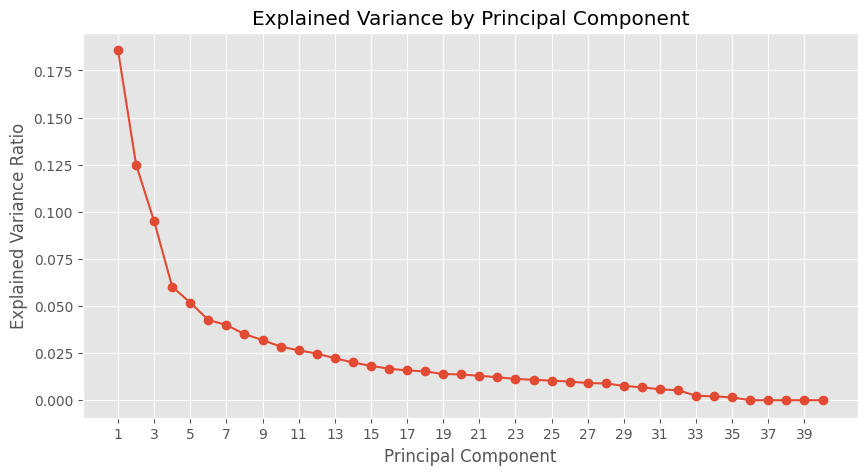

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Component")
plt.xticks(range(1, len(explained_variance_ratio) + 1, 2))
plt.grid(True)
plt.show()


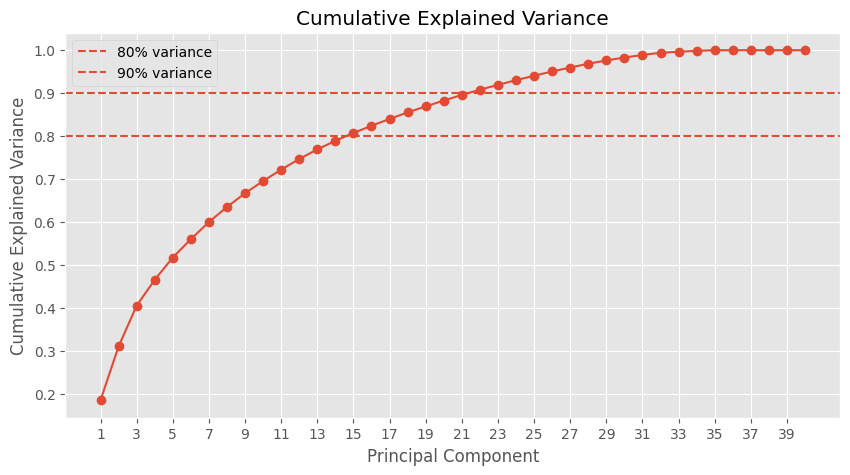

In [8]:

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(cumulative_explained_variance) + 1),
    cumulative_explained_variance,
    marker="o"
)
plt.axhline(0.80, linestyle="--", label="80% variance")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_explained_variance) + 1, 2))
plt.legend()
plt.grid(True)
plt.show()


## 2.5 Project the observations onto the first two principal components

The following scatterplot is the main visualization required by the issue.  
Each point is an AIMO observation, and the color shows its cluster assignment from the clustering task.

In [9]:

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": y.astype(str)
})

cluster_counts = pca_df["Cluster"].value_counts().sort_index()
cluster_counts


Cluster
0    1393
1     701
Name: count, dtype: int64

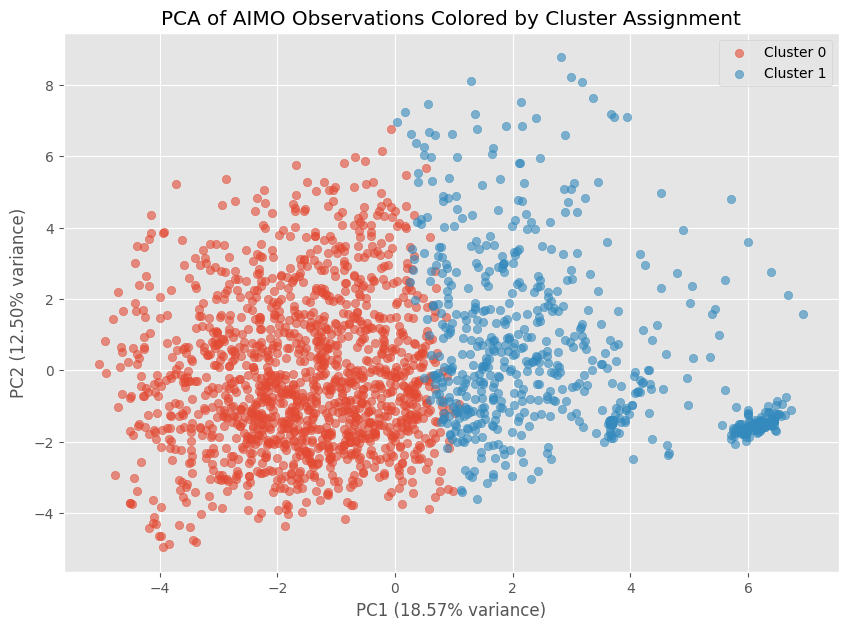

In [10]:

plt.figure(figsize=(10, 7))

for cluster_label in sorted(pca_df["Cluster"].unique()):
    mask = pca_df["Cluster"] == cluster_label
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        alpha=0.6,
        label=f"Cluster {cluster_label}"
    )

plt.xlabel(f"PC1 ({explained_variance_ratio[0]:.2%} variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1]:.2%} variance)")
plt.title("PCA of AIMO Observations Colored by Cluster Assignment")
plt.legend()
plt.grid(True)
plt.show()


## 2.6. Cluster separation in PC space

To make the separation easier to interpret, we can compare the cluster centers in the PCA projection.


In [11]:

pca_cluster_summary = pca_df.groupby("Cluster")[["PC1", "PC2"]].agg(["mean", "std", "min", "max", "count"])
pca_cluster_summary


PC1                                           PC2            \
             mean       std       min       max count      mean       std   
Cluster                                                                     
0       -1.570246  1.339862 -5.030407  1.091974  1393 -0.165564  2.133781   
1        3.120332  1.999224  0.041481  6.940333   701  0.329002  2.396339   

                                   
              min       max count  
Cluster                            
0       -4.954586  6.769967  1393  
1       -3.607924  8.773168   701

### Interpretation of the PCA scatterplot

- The clusters show their strongest separation along **PC1**.
- The average PC1 values are approximately:
  - **Cluster 0:** **-1.570**
  - **Cluster 1:** **3.120**
- The distributions still overlap, especially along **PC2**.

### Interpretation of PCA Visualization

- The PCA projection reveals that the clusters are primarily separated along PC1, with cluster 0 centered around negative PC1 values and cluster 1 around positive values.

- This indicates that while the clustering algorithm successfully captured an underlying structure in the data, the separation between groups is not sharply defined. Instead, the observations appear to lie on a continuous spectrum of movement patterns rather than forming completely distinct categories.

- This observation is consistent with the relatively low silhouette score obtained in the clustering analysis, confirming that cluster separation is moderate rather than strong.

So the PCA visualization supports the clustering result, while also showing that separation is moderate rather than strong


# Part 3. Connecting PCA to Clustering

### What PC1 Represents
PC1 (18.57% variance) is strongly loaded by:
- No_10_Angle_Deviation (0.30)
- No_4_NASM_Deviation (0.30)
- No_13_Angle_Deviation (0.30)

**Interpretation:** PC1 represents **overall movement quality**
- Negative PC1 → Less deviation → Better movers (Cluster 0)
- Positive PC1 → More deviation → Worse movers (Cluster 1)

**This aligns with our clusters**
- Cluster 0 centers at PC1 ~ -1.57 
- Cluster 1 centers at PC1 ~ +3.12

### What PC2 Represents
PC2 (12.5% variance) is strongly loaded by:
- No_8_Angle_Deviation (0.27)
- No_8_NASM_Deviation (0.27)
- No_10_NASM_Deviation (0.26)

**Interpretation:** PC2 represents **specific movement patterns**
- Captures variation WITHIN performance levels
- High PC2 → Different type of deviation pattern
- Explains why some good performers differ from each other

### Cluster Separation Analysis

From the scatter plot:
- **PC1 direction**: Clear separation 
- **PC2 direction**: Overlapping

**Conclusion:** 
Clusters are primarily differentiated by overall movement quality (PC1), 
not by specific movement types (PC2).

# 4. Overall Conclusions & Recommendations

### 4.1 Summary of Findings

### Clustering Results
**Identified 2 meaningful clusters** using K-Means (k=2)
- **Cluster 0** (66.5%): Good performers, AIMO score = 0.64
- **Cluster 1** (33.5%): Poor performers, AIMO score = 0.44

**Clear performance differentiation:**
- Cluster 0 has 47% higher AIMO scores
- Distinct feature deviation patterns
- Moderate silhouette scores (0.13-0.14) indicate real but not sharp separation

**Clusters show overlap:**
- Movement quality exists on spectrum
- Some individuals are borderline
- Not all variation captured by clustering

### PCA Results
**Successfully reduced 40 features to 2 principal components**
- PC1 (18.57%): Overall movement quality
- PC2 (12.5%): Specific movement patterns
- Together explain 31.07% of variance

**PCA validates clustering:**
- Clear cluster separation along PC1
- PC1 aligns with AIMO scores
- Confirms movement quality as primary differentiator

**Visualized complex data in interpretable 2D space**
- Enables visual inspection of patterns
- Facilitates communication with non-technical stakeholders

### 4.2 Interpretation of Movement Patterns

1. **Key Differentiating Features:**
   - Angular deviations (especially No_10, No_13)
   - NASM compliance (especially No_4)
   - These features contribute most to PC1 and cluster separation

2. **Continuous Spectrum:**
   - Movement quality is not binary
   - Overlap between clusters reflects natural variation
   - Individual assessment should consider both cluster AND score

### 4.3 Limitations

### Clustering Limitations
1. **Moderate Separation:** Silhouette score of 0.137 indicates clusters are real but overlapping
2. **Forced Discrete Boundaries:** K-Means imposes hard boundaries on continuous data
3. **Assumes Spherical Clusters:** May not capture complex, non-linear patterns
4. **Sensitive to Outliers:** Extreme values can shift cluster centers

### PCA Limitations
1. **Low Variance Explained:** Only 31.07% with 2 components
   - 68.93% of variation in higher dimensions
2. **Linear Assumption:** PCA only captures linear relationships
   - Non-linear patterns may exist
3. **Interpretation Challenge:** Components are combinations of features
   - Not as intuitive as original features